# 03 — Sectors in the sky: an independent reproduction of a CMB bound on a discrete dark-energy transition

If the cosmological constant sits on a lattice of flux **sectors** (Bousso–Polchinski; Kaloper's
discretely evanescent dark energy), its late-time evolution is a *walk on an integer sector* — a
**discrete cascade** — rather than a continuous roll. The background expansion history cannot tell the
two apart at present precision. A completed first-order phase transition, however, leaves a
*fluctuation-level* signature a smooth roll cannot: bubbles complete at slightly different times in
different places, and CMB photons crossing the "first-encounter surface" are redshifted by different
amounts.

Koren, Tsai and Wang (arXiv:2509.07076) turned this into a bound on the fraction $r$ of dark energy a
completed late-time transition can release, as a function of the transition rate $\beta/H_\star$ and its
completion redshift $\bar z_{\rm pt}$: roughly $r \lesssim 10^{-5}(\beta/H_\star)^2$ (their Eq. 15). **This
notebook reproduces that bound independently**, from their published equations, against the real
Planck 2018 temperature power spectrum (`data/planck2018_tt_full/`, from the Planck Legacy Archive).

**What is and is not claimed.** This is a *reproduction check* of someone else's published bound, not
new physics and not a new constraint. No mapping exists from this project's toy superfluid
simulations (notebook 02) to a cosmological transition rate $\beta/H_\star$ or released fraction $r$ —
none is constructed or implied. The discrete-cascade hypothesis is the cited literature's; what the
theory contributes is the reading ("the sector is the cause") and this honest, checkable test.

## Pipeline (no Boltzmann code, no MCMC, no GPU)

1. The **bubble-time power spectrum** $\mathcal P_{\delta t}$ — from the *exact* correlator of Elor,
   Jinno, Kumar, McGehee, Tsai (arXiv:2311.16222, Supplementary Eqs. S1–S16), a sum of two 1-D
   integrals, Fourier-transformed.
2. The redshift-fluctuation spectrum $\mathcal P_{\delta z_0}\propto r^2\,\mathcal I_{\delta t}$ (KTW Eqs. 9–12).
3. A Bessel-function line-of-sight projection onto the temperature power spectrum
   $D_\ell^{TT,\rm pt}$ (KTW Eq. 13).
4. A three-bin $\chi^2$ against Planck's published $1\sigma$ error bars; $\chi^2 = 5.99$ is the $2\sigma$
   bound (KTW Eq. 14). Since $D_\ell^{TT,\rm pt}\propto r^2$ exactly, $\chi^2\propto r^4$ and the bound is
   solved in closed form.

The implementation below is a vectorised NumPy port of the origin repository's
`exploration/cmb/{pdt_exact,cmb_cascade,cmb_bound,fisher_forecast}.py`; it reproduces that code's
documented numbers, and runs a bound point in seconds rather than minutes.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special
import sct_style as S
S.apply()

FULL_GRID = False   # set True to recompute all 12 exact bound points live (≈3–4 min); default computes 4

## 1. The exact bubble-completion-time correlator, and its landmark

$\beta^2\langle\delta t_c(x)\,\delta t_c(y)\rangle(r)$ = single-bubble (Eq. S11) + double-bubble (Eq. S16)
contributions, each a finite integral over $t_{xy}\in[-r,r]$ (lengths in units of $v_w/\beta$). At $r\to0$
the double-bubble term vanishes and the single-bubble term reduces to $\pi^2/6$ exactly — a closed-form
landmark, independent of any code.

In [2]:
def _I(t, r):
    return 8 * np.pi * (np.exp(t / 2) + np.exp(-t / 2) + (t**2 - (r**2 + 4 * r)) / (4 * r) * np.exp(-r / 2))

def _single(t, r):
    I = _I(t, r)
    return (2 * np.pi * np.exp(-r / 2) / (r * I)) * (r**2 / 4 + r + 2 - t**2 / 4) * (np.log(I / (8 * np.pi))**2 - t**2 / 4 + np.pi**2 / 6)

def _double(t, r):
    I = _I(t, r)
    B = (np.exp(-t / 2 - r / 2) / (2 * r)) * (r + t + 4) * (r - t)
    Cc = (np.exp(t / 2 - r / 2) / (2 * r)) * (r - t + 4) * (r + t)
    D = (np.exp(-r) / (16 * r**2)) * ((r + 4)**2 - t**2) * (r**2 - t**2)
    return (16 * np.pi**2 / I**2) * (4 - B - Cc + D) * ((np.log(I / (8 * np.pi)) - 1)**2 - t**2 / 4 + np.pi**2 / 6 - 1)

def correlator(r):
    r = max(r, 1e-4)
    return (integrate.quad(_single, -r, r, args=(r,), limit=200)[0]
            + integrate.quad(_double, -r, r, args=(r,), limit=200)[0])

t0 = time.time()
R_GRID = np.linspace(1e-4, 45.0, 250)
C_GRID = np.array([correlator(r) for r in R_GRID])
print(f"correlator table: 250 points in {time.time() - t0:.1f} s")
print(f"correlator(r→0) = {C_GRID[0]:.10f}     π²/6 = {np.pi**2 / 6:.10f}")

correlator table: 250 points in 3.9 s
correlator(r→0) = 1.6449340652     π²/6 = 1.6449340668


## 2. The bubble-time power spectrum: exact vs. the earlier interpolation

The dimensionless spectrum (Eq. S1–S2) is a Fourier sine transform of that table. A first reproduction
pass had to *interpolate* between the spectrum's two published power-law limits, because no closed
form for the full curve is printed in either paper; the exact correlator removes that approximation.
The plot shows why it mattered: the interpolation peaks at the wrong wavenumber.

exact spectrum peak:        k/β = 0.494, value = 1.077   (Elor et al. Fig. S4: ≈1 near k/β≈0.5)
interpolation peak:         k/β = 0.284, value = 0.866


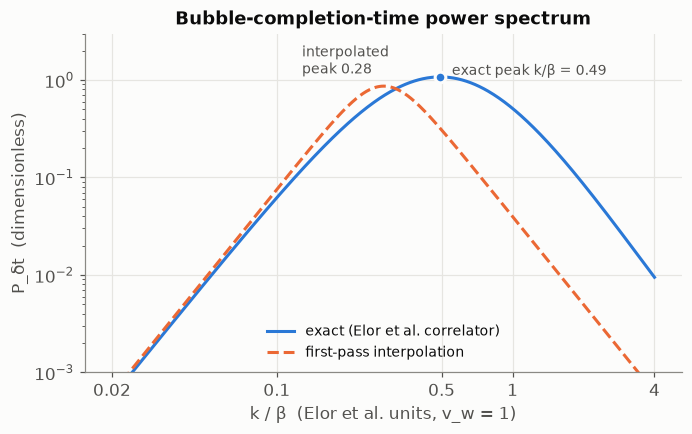

In [3]:
def P_exact(k):
    # Eq. (S1)-(S2): Fourier sine transform of the correlator table, vectorised over k (Elor's k/β units)
    k = np.maximum(np.atleast_1d(np.asarray(k, float)), 1e-8)
    sinc = np.sinc(np.outer(k, R_GRID) / np.pi)
    P = np.trapezoid(4 * np.pi * R_GRID**2 * sinc * C_GRID, R_GRID, axis=1)
    return np.maximum(0.0, k**3 / (2 * np.pi**2) * P)

def P_interp(k):
    # first-pass two-asymptote interpolation, in KTW's variable ξ = (8π)^(1/3) k
    xi = (8 * np.pi) ** (1 / 3) * np.asarray(k, float)
    return 1.0 / (1.0 / (3 * xi**3) + xi**3)

kf = np.geomspace(0.02, 4, 500)
Pe, Pi = P_exact(kf), P_interp(kf)
ke, ki = kf[np.argmax(Pe)], kf[np.argmax(Pi)]
print(f"exact spectrum peak:        k/β = {ke:.3f}, value = {Pe.max():.3f}   (Elor et al. Fig. S4: ≈1 near k/β≈0.5)")
print(f"interpolation peak:         k/β = {ki:.3f}, value = {Pi.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kf, Pe, color=S.BLUE, label="exact (Elor et al. correlator)")
ax.plot(kf, Pi, color=S.ORANGE, ls="--", label="first-pass interpolation")
ax.plot([ke], [Pe.max()], "o", color=S.BLUE, mec=S.SURFACE, mew=2)
ax.text(ke * 1.12, Pe.max() * 1.05, f"exact peak k/β = {ke:.2f}", color=S.INK_2, fontsize=9)
ax.text(ki * 0.45, Pi.max() * 1.35, f"interpolated\npeak {ki:.2f}", color=S.INK_2, fontsize=9)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(1e-3, 3)
S.plain_log_ticks(ax.xaxis, [0.02, 0.1, 0.5, 1, 4])
ax.set_xlabel("k / β  (Elor et al. units, v_w = 1)"); ax.set_ylabel("P_δt  (dimensionless)")
ax.set_title("Bubble-completion-time power spectrum")
ax.legend(loc="lower center", fontsize=9)
S.save(fig, "03_bubble_time_spectrum"); plt.show()

## 3. From bubbles to the CMB: $D_\ell^{TT,\rm pt}$ against Planck's error bars

Background: Planck 2018 best fit as KTW adopt it ($H_0=68$, $\Omega_\Lambda=0.69$, $\Omega_m=0.31$).
The integration windows in $k$ are one decade either side of the spectrum's peak, as in the paper; the
$\mu$K² normalisation multiplies by $T_{\rm CMB}^2$ (not spelled out in Eq. 13, but required to match
KTW's $\mu$K² axis — an assumption stated here, as in the origin design document).

In [4]:
H0, Om, OL = 68.0, 0.31, 0.69
C_LIGHT, T_CMB_uK = 299792.458, 2.7255e6
H0_invMpc = H0 / C_LIGHT
E = lambda z: np.sqrt(OL + Om * (1 + z) ** 3)
chi0 = lambda zi, zf: integrate.quad(lambda z: 1 / ((1 + z) * H0_invMpc * E(z)), zf, zi, limit=200)[0]
XI_PEAK = ke * (8 * np.pi) ** (1 / 3)          # the exact spectrum's peak, in KTW's ξ
MU, MU_W = np.polynomial.legendre.leggauss(16)

def Pdt(hk, zpt, bh):                         # KTW's 𝒫_δt at ĥk = k/H★ (Eq. 2-3 conventions)
    return P_exact((1 + zpt) * np.asarray(hk) / bh) / bh**2

def hk_of_xi(xi, zpt, bh):
    return xi * bh / ((8 * np.pi) ** (1 / 3) * (1 + zpt))

def I_dt(hk_arr, zpt, bh, n_r=40):            # Eq. (12), vectorised over k, r and μ
    hp = hk_of_xi(XI_PEAK, zpt, bh)
    lr = np.linspace(np.log(hp / 10), np.log(hp * 10), n_r); rg = np.exp(lr)
    hk = np.asarray(hk_arr)[:, None, None]
    s = np.clip(np.sqrt(hk**2 + rg[None, :, None]**2 - 2 * hk * rg[None, :, None] * MU), 1e-12, None)
    inner = np.sum(MU_W * Pdt(s.ravel(), zpt, bh).reshape(s.shape) / s**3, axis=2)
    return np.asarray(hk_arr) ** 3 * np.trapezoid(Pdt(rg, zpt, bh)[None, :] * inner, lr, axis=1)

def D_ell_pt(ells, zpt, r_pt, bh, n_k=60):    # Eq. (11) and (13), in μK²
    Hs, Dtau = H0_invMpc * E(zpt), chi0(zpt, 0.0)
    hp = hk_of_xi(XI_PEAK, zpt, bh)
    lk = np.linspace(np.log(hp / 10), np.log(hp * 10), n_k); hk = np.exp(lk)
    Pz0 = r_pt**2 * OL**2 * (OL + Om * (1 + zpt) ** 3) ** (-3) * I_dt(hk, zpt, bh)
    return np.array([2 * l * (l + 1) * np.trapezoid(Pz0 * special.spherical_jn(int(l), hk * Hs * Dtau) ** 2, lk)
                     * T_CMB_uK**2 for l in np.atleast_1d(ells)])

ELL, DL, DM, DP = np.loadtxt(S.DATA / "planck2018_tt_full" / "COM_PowerSpect_CMB-TT-full_R3.01.txt", unpack=True)
SIG = 0.5 * (DM + DP)                          # symmetrised Planck 1σ bar, μK²
print(f"Planck table: ℓ = {int(ELL[0])}..{int(ELL[-1])};  D_220 = {DL[ELL == 220][0]:.0f} μK² (first acoustic peak)")

Planck table: ℓ = 2..2508;  D_220 = 6373 μK² (first acoustic peak)


β/H★ =  40: D_ℓ peaks at ℓ = 2, max 30605 μK²   (2.5 s)


β/H★ = 100: D_ℓ peaks at ℓ = 5, max 848 μK²   (2.1 s)


β/H★ = 200: D_ℓ peaks at ℓ = 11, max 54 μK²   (2.0 s)


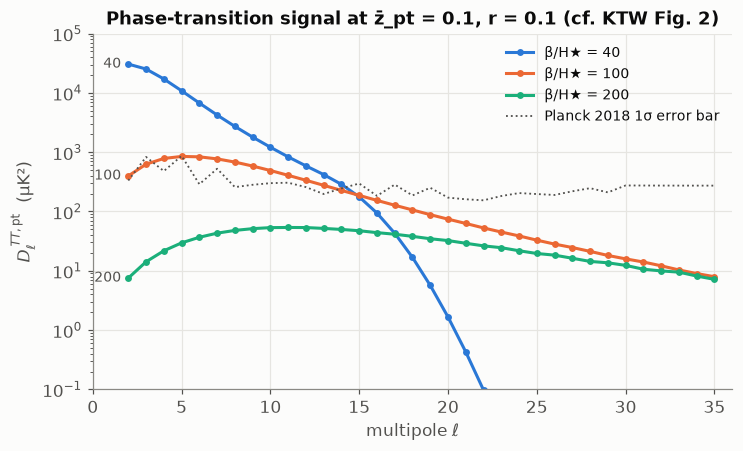

In [5]:
ells = np.arange(2, 36)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for bh, c in ((40, S.BLUE), (100, S.ORANGE), (200, S.AQUA)):
    t0 = time.time(); D = D_ell_pt(ells, 0.1, 0.1, bh)
    ax.plot(ells, D, "-o", color=c, ms=3.5, label=f"β/H★ = {bh}")
    ax.text(1.6, D[0], f"{bh}", color=S.INK_2, va="center", ha="right", fontsize=9)
    print(f"β/H★ = {bh:3d}: D_ℓ peaks at ℓ = {ells[np.argmax(D)]}, max {D.max():.0f} μK²   ({time.time() - t0:.1f} s)")
m = (ELL >= 2) & (ELL <= 35)
ax.plot(ELL[m], SIG[m], color=S.INK_2, lw=1.2, ls=":", label="Planck 2018 1σ error bar")
ax.set_yscale("log"); ax.set_ylim(0.1, 1e5); ax.set_xlim(0, 36)
ax.set_xlabel("multipole ℓ"); ax.set_ylabel(r"$D_\ell^{\,TT,\mathrm{pt}}$  (μK²)")
ax.set_title("Phase-transition signal at z̄_pt = 0.1, r = 0.1 (cf. KTW Fig. 2)")
ax.legend(fontsize=9, loc="upper right")
S.save(fig, "03_Dell_vs_planck"); plt.show()

## 4. The $2\sigma$ bound, computed live

Peak-finding uses the same sparse multipole grid as the origin code ($\ell\in\{3,5,7,9,12,15,20,25,30,40\}$),
so the numbers are directly comparable. By default four representative points are recomputed; set
`FULL_GRID = True` in the first code cell to recompute all twelve.

In [6]:
GRID = (3, 5, 7, 9, 12, 15, 20, 25, 30, 40)
sigma_planck = lambda l: SIG[int(np.argmin(np.abs(ELL - l)))]

def r_bound(zpt, bh, sigma=sigma_planck, r_probe=0.1, chi2_target=5.99):
    vals = D_ell_pt(GRID, zpt, r_probe, bh)
    lp = GRID[int(np.argmax(vals))]
    ls = [l for l in (lp - 1, lp, lp + 1) if l >= 2]
    chi2 = sum((d / sigma(l)) ** 2 for d, l in zip(D_ell_pt(ls, zpt, r_probe, bh), ls))
    return r_probe * (chi2_target / chi2) ** 0.25, lp       # χ² ∝ r⁴ exactly (Eq. 11)

import csv
def read_csv(name):
    rows = [r for r in open(S.DATA / "results" / "cmb" / name) if not r.startswith("#")]
    return list(csv.DictReader(rows))
py = {(float(r["beta_over_H"]), float(r["zpt"])): r for r in read_csv("python_bound_table_interp_vs_exact.csv")}
rs = {(float(r["beta_over_H"]), float(r["zpt"])): r for r in read_csv("rust_fisher_grid_pr57.csv")}

points = list(py) if FULL_GRID else [(10.0, 0.1), (100.0, 0.1), (500.0, 0.1), (50.0, 0.2)]
live = {}
print(f"{'β/H★':>6} {'z_pt':>5} {'ℓ_p':>4} {'r (live)':>10} {'r (Python, archived)':>21} {'r (Rust PR #57)':>16} {'KTW Eq.15':>10} {'time':>6}")
for bh, z in points:
    t0 = time.time(); r_live, lp = r_bound(z, bh); live[(bh, z)] = r_live
    print(f"{bh:6.0f} {z:5.2f} {lp:4d} {r_live:10.5f} {float(py[(bh, z)]['r_exact']):21.5f} "
          f"{float(rs[(bh, z)]['r_planck']):16.5f} {1e-5 * bh**2:10.4f} {time.time() - t0:5.1f}s")

  β/H★  z_pt  ℓ_p   r (live)  r (Python, archived)  r (Rust PR #57)  KTW Eq.15   time


    10  0.10    3    0.00316               0.00316          0.00310     0.0010   4.7s


   100  0.10    5    0.08405               0.08405          0.08407     0.1000   5.5s


   500  0.10   25    1.42461               1.42500          1.42501     2.5000   5.1s


    50  0.20    5    0.02494               0.02494          0.02494     0.0250   5.2s


The live values reproduce the origin repository's archived exact-spectrum numbers. The pure-Rust port
in rusty-SUNDIALS (`crates/qf-cmb-cascade`, [PR #57](https://github.com/xaviercallens/rusty-SUNDIALS/pull/57))
agrees closely, with a residual of a few percent at the lowest transition rate (different quadrature
construction and summation order), and completed the full grid — including the forecast in §6 — in
about nine minutes, where the original Python version could not finish in one session.

## 5. How the reproduction compares with the published approximation

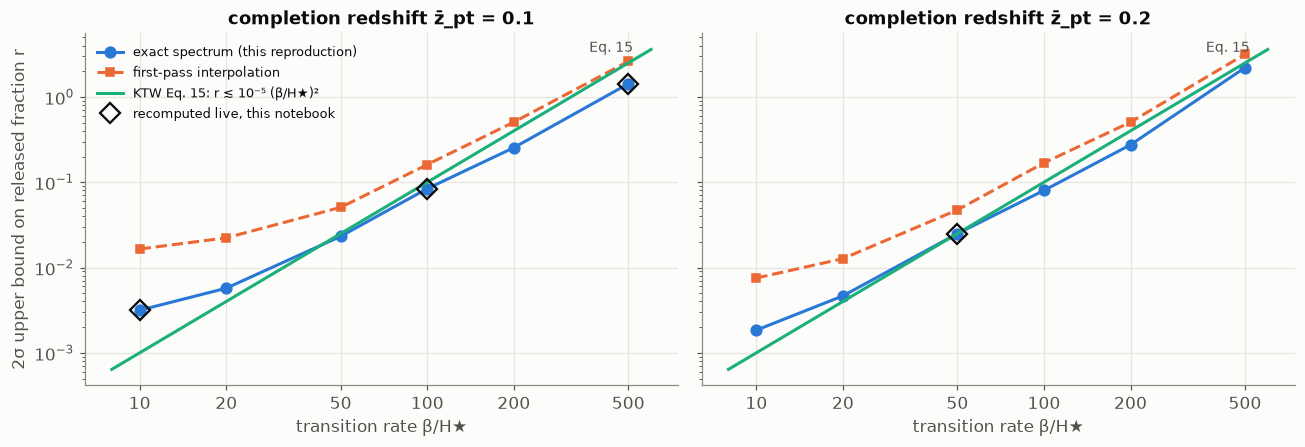

  β/H★    z  exact/Eq15  interp/Eq15
    10  0.1       3.16×       16.48×
    20  0.1       1.43×        5.57×
    50  0.1       0.93×        2.03×
   100  0.1       0.84×        1.61×
   200  0.1       0.64×        1.27×
   500  0.1       0.57×        1.04×
    10  0.2       1.84×        7.54×
    20  0.2       1.16×        3.18×
    50  0.2       1.00×        1.89×
   100  0.2       0.80×        1.69×
   200  0.2       0.69×        1.26×
   500  0.2       0.88×        1.26×


In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, z in zip(axs, (0.1, 0.2)):
    keys = sorted(k for k in py if k[1] == z)
    b = np.array([k[0] for k in keys])
    ax.plot(b, [float(py[k]["r_exact"]) for k in keys], "-o", color=S.BLUE, label="exact spectrum (this reproduction)")
    ax.plot(b, [float(py[k]["r_interp"]) for k in keys], "--s", color=S.ORANGE, ms=5, label="first-pass interpolation")
    bb = np.geomspace(8, 600, 50)
    ax.plot(bb, 1e-5 * bb**2, color=S.AQUA, label="KTW Eq. 15: r ≲ 10⁻⁵ (β/H★)²")
    lk = [k for k in live if k[1] == z]
    if lk:
        ax.plot([k[0] for k in lk], [live[k] for k in lk], "D", ms=9, mfc="none", mec=S.INK, mew=1.5, label="recomputed live, this notebook")
    ax.text(520, 1e-5 * 520**2 * 1.25, "Eq. 15", color=S.INK_2, fontsize=9, ha="right")
    ax.set_xscale("log"); ax.set_yscale("log"); S.plain_log_ticks(ax.xaxis, [10, 20, 50, 100, 200, 500])
    ax.set_xlabel("transition rate β/H★"); ax.set_title(f"completion redshift z̄_pt = {z}")
axs[0].set_ylabel("2σ upper bound on released fraction r")
axs[0].legend(fontsize=8.5, loc="upper left")
fig.tight_layout(); S.save(fig, "03_bound_comparison"); plt.show()

print(f"{'β/H★':>6} {'z':>4} {'exact/Eq15':>11} {'interp/Eq15':>12}")
for k in sorted(py, key=lambda k: (k[1], k[0])):
    e15 = float(py[k]["KTW_eq15"])
    print(f"{k[0]:6.0f} {k[1]:4.1f} {float(py[k]['r_exact']) / e15:10.2f}× {float(py[k]['r_interp']) / e15:11.2f}×")

**Honest reading.** Eq. 15 is, in its authors' own words, "a useful analytic order-of-magnitude
approximation" built from the spectrum's peak value alone. Against it, the exact reproduction's
worst-case disagreement across the grid is a factor 3.16 (at $\beta/H_\star=10$), down from 16.5 with the
interpolation — but not uniformly better: at the highest rates the exact result sits 30–45% *below*
the approximation where the interpolation had been within 27%. The two passes do not bracket the truth
from the same side. Neither is a check on KTW's full numerical Fig. 3, which was not re-extracted.

## 6. Could a better telescope tighten the bound? The cosmic-variance floor

Because $\chi^2\propto r^4/\sigma_\ell^2$, the bound scales exactly as $r\propto\sigma_\ell^{1/2}$. No
temperature-only experiment can beat cosmic variance: only $2\ell+1$ modes exist per multipole,
$\sigma_{\rm CV}(\ell)=D_\ell\sqrt{2/((2\ell+1)f_{\rm sky})}$ (here $f_{\rm sky}=0.7$). So the question is
how close Planck already is to that floor where this signal lives.

  ℓ  σ_Planck/σ_CV
  2           1.95
  3           1.39
  5           1.13
 10           1.01
 15           0.96
 20           0.98
 30           1.15
 40           0.85
 50           0.99
ℓ = 5–29 : ratio 0.96–1.13 (median 1.00)
ℓ = 30–50: ratio 0.83–1.84 (median 1.15)  ← the bars change character here


ℓ = 30–50 vs a smoothed floor: ratio 1.03–1.42 (median 1.15)



β/H★ = 10, z = 0.1 (the most improvable point): r(Planck) = 0.00316, r(CV floor) = 0.00226, tightening 1.39×   (9.6 s)


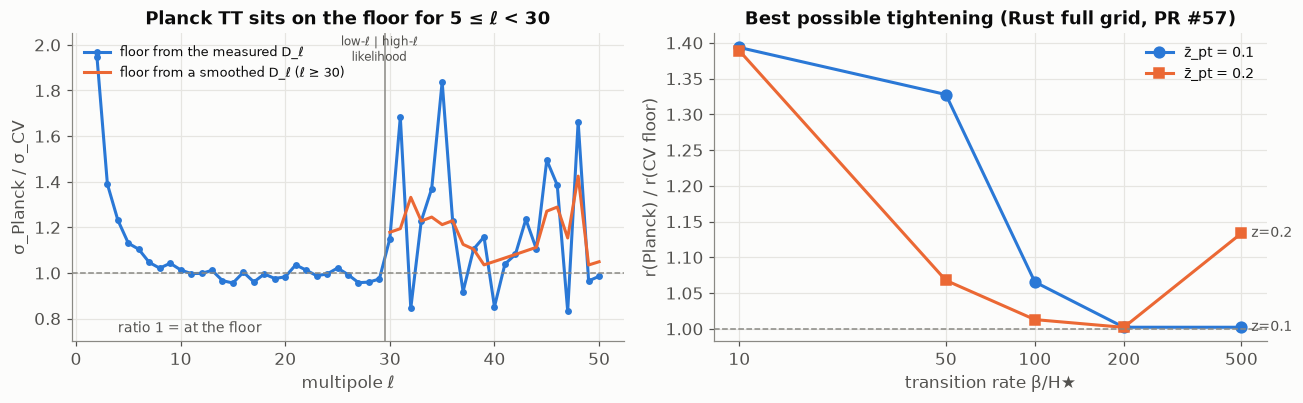

In [8]:
F_SKY = 0.7
sigma_cv = lambda l: DL[int(np.argmin(np.abs(ELL - l)))] * np.sqrt(2 / ((2 * l + 1) * F_SKY))
ls = np.arange(2, 51)
ratio = np.array([sigma_planck(l) / sigma_cv(l) for l in ls])
print(f"{'ℓ':>3} {'σ_Planck/σ_CV':>14}")
for l in (2, 3, 5, 10, 15, 20, 30, 40, 50):
    print(f"{l:3d} {sigma_planck(l) / sigma_cv(l):14.2f}")
low = (ls >= 5) & (ls < 30); high = ls >= 30
print(f"ℓ = 5–29 : ratio {ratio[low].min():.2f}–{ratio[low].max():.2f} (median {np.median(ratio[low]):.2f})")
print(f"ℓ = 30–50: ratio {ratio[high].min():.2f}–{ratio[high].max():.2f} (median {np.median(ratio[high]):.2f})  ← the bars change character here")
# From ℓ = 30 the table's error bars are smooth in ℓ (Planck's high-ℓ likelihood), while the measured D_ℓ
# still scatters by ~±√(2/(2ℓ+1)). Comparing smooth bars with a floor built from the scattering D_ℓ
# produces the spread above; compare instead with a floor built from a running median of D_ℓ:
DL_s = np.array([np.median(DL[max(0, i - 3): i + 4]) for i in range(len(DL))])
sigma_cv_s = lambda l: DL_s[int(np.argmin(np.abs(ELL - l)))] * np.sqrt(2 / ((2 * l + 1) * F_SKY))
ratio_s = np.array([sigma_planck(l) / sigma_cv_s(l) for l in ls])
print(f"ℓ = 30–50 vs a smoothed floor: ratio {ratio_s[high].min():.2f}–{ratio_s[high].max():.2f} (median {np.median(ratio_s[high]):.2f})")

t0 = time.time()
r_pl, _ = r_bound(0.1, 10); r_cv, _ = r_bound(0.1, 10, sigma=sigma_cv)
print(f"\nβ/H★ = 10, z = 0.1 (the most improvable point): r(Planck) = {r_pl:.5f}, r(CV floor) = {r_cv:.5f}, "
      f"tightening {r_pl / r_cv:.2f}×   ({time.time() - t0:.1f} s)")

fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axs[0]
ax.plot(ls, ratio, "-o", color=S.BLUE, ms=3.5, label="floor from the measured D_ℓ")
ax.plot(ls[high], ratio_s[high], "-", color=S.ORANGE, label="floor from a smoothed D_ℓ (ℓ ≥ 30)")
ax.axhline(1, color=S.MUTED, lw=1, ls="--"); ax.text(4, 0.74, "ratio 1 = at the floor", color=S.INK_2, fontsize=9)
ax.axvline(29.5, color=S.MUTED, lw=1); ax.text(29, 1.93, "low-ℓ | high-ℓ\nlikelihood", ha="center", color=S.INK_2, fontsize=8)
ax.set_ylim(0.7, 2.05); ax.legend(fontsize=8.5, loc="upper left")
ax.set_xlabel("multipole ℓ"); ax.set_ylabel("σ_Planck / σ_CV"); ax.set_title("Planck TT sits on the floor for 5 ≤ ℓ < 30")
ax = axs[1]
fk = sorted((k for k in rs if rs[k]["r_cv"]), key=lambda k: (k[1], k[0]))
for z, c, mk in ((0.1, S.BLUE, "o"), (0.2, S.ORANGE, "s")):
    kk = [k for k in fk if k[1] == z]
    t = [float(rs[k]["r_planck"]) / float(rs[k]["r_cv"]) for k in kk]
    ax.plot([k[0] for k in kk], t, "-" + mk, color=c, label=f"z̄_pt = {z}")
    ax.text(kk[-1][0] * 1.08, t[-1], f"z={z}", color=S.INK_2, fontsize=9, va="center")
ax.axhline(1, color=S.MUTED, lw=1, ls="--")
ax.set_xscale("log"); S.plain_log_ticks(ax.xaxis, [10, 50, 100, 200, 500])
ax.set_xlabel("transition rate β/H★"); ax.set_ylabel("r(Planck) / r(CV floor)")
ax.set_title("Best possible tightening (Rust full grid, PR #57)"); ax.legend(fontsize=9)
fig.tight_layout(); S.save(fig, "03_cosmic_variance_floor"); plt.show()

Two regimes show up in Planck's own table. For $\ell<30$ — where this signal peaks for most of the
grid ($\ell_p$ = 3–25 at eleven of the twelve points) — the published error bars *are* the cosmic-variance floor of the measured
spectrum, to within about 13%: at the largest scales Planck is not noise-limited at all. From $\ell=30$
the bars change character (they come from Planck's high-$\ell$ likelihood and are smooth in $\ell$),
so comparing them multipole-by-multipole with a floor built from the *scattering* measured $D_\ell$
gives a spread up to ≈1.8 that says more about that scatter than about the telescope; against a
smoothed floor they sit at 1.0–1.4× (median 1.15, printed above). (An earlier version of this analysis sampled nine
multipoles and summarised the whole range as "within 15%"; scanning every multipole shows the
two-regime structure instead.) What matters for the bound is the three-bin $\chi^2$ at the signal's
peak, and the full Rust grid gives the answer directly: the largest possible improvement anywhere on the grid is about $1.4\times$ in $r$,
at the lowest transition rate, and it comes entirely from $\ell=2,3$, where the published bars exceed
this simple floor (asymmetric low-$\ell$ posteriors and the assumed $f_{\rm sky}$ both enter there) —
while the floor itself, a count of the modes the sky contains, cannot be lowered by any instrument. **No temperature-only successor to Planck — a bigger
mirror, a colder detector — can meaningfully tighten this bound.** Further progress, as KTW and Elor et
al. themselves point out, belongs to different channels: CMB spectral distortions and pulsar timing
arrays.

## Summary

| step | status |
|---|---|
| correlator landmark $\pi^2/6$; spectrum peak $k/\beta\approx0.49$, value $\approx1.08$ | **recomputed live** |
| $D_\ell^{TT,\rm pt}$ for three transition rates vs. Planck | **recomputed live** |
| $2\sigma$ bound: 4 points (12 with `FULL_GRID`) | **recomputed live**, matches the archived Python table and the Rust port |
| interpolated vs. exact vs. Eq. 15 across the grid | **replotted** from `data/results/cmb/python_bound_table_interp_vs_exact.csv` |
| Planck/cosmic-variance ratio | **recomputed live** from the Planck table |
| full Fisher grid | **replotted** from `data/results/cmb/rust_fisher_grid_pr57.csv` (rusty-SUNDIALS PR #57) |

None of this required specialised hardware: every number here is a closed-form or exact-scaling
calculation, computed on one CPU core. And none of it maps this project's superfluid simulations onto
a cosmological transition — that bridge does not exist, and building one by analogy would be exactly
the error this theory's discipline (check dependencies, not analogy) exists to prevent.